In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import sys
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import zscore, variation
from sklearn.preprocessing import normalize, scale, MinMaxScaler
import seaborn as sns

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
def accessData(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=False,  header=None)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1

    return dic_dataframes

def accessData2(list_files, path, list_labels):
    """opens the read/transcript/gene counts of each file"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=0,  header=None)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    
    return dic_dataframes

def accessData3(list_files, path, list_labels):
    """opens the read/transcript/gene counts of each file"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    
    return dic_dataframes


def accessData4(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,4,5,6,7,8,9],  header=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    return dic_dataframes

def accessData5(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=False,  header=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1

    return dic_dataframes

def saveCSV(dic_data, path, label):
    """Save dataframes inside dictionary to csv files"""
    for key in dic_data:
        dic_data[key].to_csv(path+key+label+'.bed', sep='\t', header=False)

    return print('Files saved')

def saveCSV2(dic_data, path, label):
    """Save dataframes inside dictionary to csv files"""
    for key in dic_data:
        dic_data[key].to_csv(path+key+label+'.bed', sep='\t', header=True)

    return print('Files saved')


def normalize(dic_data, dic_total, dic_scaling_value):
    """Normalize to desired value (mean, median...)
    1. divide by the total counts in each column
    2. multiply by scaling value"""
    #make a counter for the smaple number to select the scaling_value position
    count = 0
    #make a dictionary to store the normalized datasets
    dic_normal = {}
    #Get each dataframe
    for key in dic_data:
        #divide each section by the total of the section
        data_frame_normal_s1 = dic_data[key].divide(dic_total[key], axis='columns')
        #multiply by the scaling value
        data_frame_normal = data_frame_normal_s1.multiply(dic_scaling_value[key])
        count = count + 1
        #save the dataframe to the dictionary
        dic_normal[key] = data_frame_normal

    return dic_normal

def zscores(dic_data):
    """Calculates de z scores for each gene individually"""
    #Create a dictinary to store the dataframes of z scores
    dic_zscores = {}
    for key in dic_data:
        #create a dataframe to store the zscores
        df_zscore = pd.DataFrame(columns = dic_data[key].columns, index = dic_data[key].index)
        #calculate z scores for each gene
        #for that we need to get the info from every row independently and then get the z score
        for index in dic_data[key].index.values:
            #transform the series into list, then to np.array and apply z score funtion from scipy.stats
            #and save it to the Zscore df
            data_gene = np.array(list(dic_data[key].loc[index]))
            df_zscore.loc[index] = zscore(data_gene.astype(float))
        #save the df_zscores to the dictionary
        dic_zscores[key] = df_zscore.astype(float)
    
    return dic_zscores


def scaledZscores(dic_data):
    """Calculates de scaled z scores for each gene individually.
    Normalize the Z score to scaled Z score (-1 to 1)"""
    #Create a dictinary to store the dataframes of z scores
    dic_scaled_zscores = {}
    for key in dic_data:
        #create a dataframe to store the zscores
        df_scaled_zscore = pd.DataFrame(columns = dic_data[key].columns, index = dic_data[key].index)
        #calculate z scores for each gene
        #for that we need to get the info from every row independently and then get the z score
        for index in dic_data[key].index.values:
            ## 1.convert the column value of the dataframe to floats
            float_array = dic_data[key].loc[index].values.astype(float)
            # Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.
            float_array = float_array.reshape(-1, 1)
            # 2. create a min max processing object
            min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
            scaled_array = min_max_scaler.fit_transform(float_array)
            # 3. convert the scaled array to dataframe. First reshape the array to the original shape
            scaled_array = scaled_array.reshape(len(dic_data[key].columns.values),)
            df_scaled_zscore.loc[index] = scaled_array
        #save the df_zscores to the dictionary 
        #Use astype(float) to ensure the values are numbers for correct plotting
        dic_scaled_zscores[key] = df_scaled_zscore.astype(float)
    
    return dic_scaled_zscores


def meanDataset(dic_data):
    """Sum the different datasets and calculate the mean to create a Mean dataset"""
    #get a list of the keys
    keys = []
    for key in dic_data:
        keys.append(key)
    #create a new dataframe
    mean_dataset = pd.DataFrame(index = dic_data[keys[0]].index.values, columns = dic_data[keys[0]].index.values)
    for element in range(len(keys)):
        #add each dataframe individually
        #first combine the first two dataframes
        if element == 0:
            mean_dataset = dic_data[keys[0]].add(dic_data[keys[1]], axis='index')
        #add the remaining dataframes to the existent sum
        if element > 1:
            mean_dataset = mean_dataset.add(dic_data[keys[element]], axis='index')
    #divide by the number of samples to make the mean
    mean_dataset = mean_dataset.div(len(keys))
    
    #re-normalize z-scores
    #create dic_data 
    dic_data = {'mean': mean_dataset}
    mean_dataset_scaled = scaledZscores(dic_data)
    
    return mean_dataset_scaled


## Anna's formulas for hierarchical clustering
def hierarchicalClustering(df, cth = 100, plot = False, method = 'ward', metric = 'euclidean', nolabels = 'True', leaf_colors = []):
    """performs hierarchical clustering using linkage and dendogram functions from scipy.cluster.hierarchy package"""
    if len(leaf_colors) > 0:
        hierarchy.set_link_color_palette(leaf_colors)
    Z = linkage(df, method=method, metric = metric)
    dg = dendrogram(Z, no_labels=nolabels, color_threshold=cth, no_plot = np.invert(plot))
    plt.show()
    return Z, dg

## Anna's formulas for hierarchical clustering
def hierarchicalClustering2(df, cth = 100, plot = False, method = 'average', metric = 'euclidean', nolabels = 'True', leaf_colors = []):
    """performs hierarchical clustering using linkage and dendogram functions from scipy.cluster.hierarchy package"""
    if len(leaf_colors) > 0:
        hierarchy.set_link_color_palette(leaf_colors)
    Z = linkage(df, method=method, metric = metric)
    dg = dendrogram(Z, no_labels=nolabels, color_threshold=cth, no_plot = np.invert(plot))
    plt.show()
    return Z, dg

def getClusterByColor(dg, labels):
    """given a dendogram and labels, it groups labels by colors in the dendogram (i.e. clusters)"""
    kk = []
    ii = 0
    cluster = 0
    color = dg['color_list'][0]
    clusters = {cluster: []}
    for i in range(len(dg['icoord'])):
        v = dg['icoord'][i]
        for j in [0,2]:
            vj = int(round((v[j]-5.)/10))
            if (v[j]-5.)/10 == vj and vj not in kk:
                kk.append(vj)
                if dg['color_list'][i] == color:
                    clusters[cluster].append(labels[dg['leaves'][vj]])
                else:
                    color = dg['color_list'][i]
                    cluster += 1
                    clusters[cluster] = [labels[dg['leaves'][vj]]]
    return clusters


def plotHeatmap(dic_data, dg, clusters, figsize, title, type_data, reorganize = False, new_index_order = []):
    """Use the combined clustering to plot the indivudal heatmaps for each sample"""
    #access each dictionary and count the number of samples
    keys = []
    for key in dic_data:
        keys.append(key)      
    #check the number of samples to provide the width ratios
    ratios = [0.5]
    for element in range(len(keys)):
        if element < len(keys)-1:
            ratios.append(3)
        if element == len(keys)-1:
            ratios.append(4)
    # plot multiple plots with plt.sublots. axs is a list of all the subplots. Plot as many plots as samples plus 
    # one for the cluster label
    fig, axs = plt.subplots(nrows = 1, ncols = len(keys)+1, sharey='row', gridspec_kw={'width_ratios': ratios}, figsize = figsize);
    #make a count to access the correct plot
    count = 0
    for key in dic_data:
        if reorganize == False:
            #use dg['leaves'] indexes to organize the data to plot
            data_plot = dic_data[key].loc[dic_data[key].index[dg['leaves']]]
        if reorganize == True:
            data_plot = dic_data[key].reindex(index = new_index_order)
        # to plot I use ax.imshow
        im = axs[count+1].imshow(data_plot, aspect='auto', interpolation='none')
        # add labels
        axs[count+1].set_title(key)
        #remove ticks on the y axis
        axs[count+1].tick_params(top=False, bottom=True, left=False, right=False)
        #add 1 to the count to go to next sample
        count = count + 1
        
    #create the colour bar and label it, we use the last image (im)
    #cax = divider.append_axes('left', size='5%', pad=0.05)
    cb = fig.colorbar(im, orientation='vertical', shrink = 0.3)
    cb.set_label(type_data)

    # Make a big plot in order to craete shared axis labels
    # add a big axes, hide frame
    fig.add_subplot(111, frameon=False)
    # hide tick and tick label of the big axes
    plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    plt.grid(False)
    plt.xlabel("Sections A-P")

    #Introduce the cluster bar
    #make the variable bottom to 0, which indicates were the cluster starts
    bottom = 0
    for cluster in clusters:
        if int(cluster) < len(clusters)-1: 
            #get the height of the cluster
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster labels
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')
            #add the length of the current cluster to the bottom variable for the next cluster start
            bottom = bottom + len(clusters[cluster])

        #I add -1 to the last bottom, otherwise the plot gets out of the grid
        if int(cluster) == len(clusters)-1:
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster label
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')

    #axs[0].set_ylim(0,bottom)  

    #remove ticks and plot frame from the cluster bar
    axs[0].tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    axs[0].axis('off')
    #add the figure title
    fig.suptitle(title, fontsize=13)
    plt.show()
    
    
def ClusterGeneNames(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        for element in data[start:end]:
            #split the index and save the gene id and new line
            info = element.split('_')
            f.write(str(info[1]) + '\n')
        start = start + len(clusters[key])
    #close the file when done
    f.close()
    
    return print(file_name)


def ClusterEnsambleID(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        for element in data[start:end]:
            #split the index and save the gene id and new line
            info = element.split('_')
            f.write(str(info[0]) + '\n')
        start = start + len(clusters[key])
    #close the file when done
    f.close()
    
    return print(file_name)


def ClusterIndexs(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #create new dictiornary
    idx_cluster={}
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        list_idx=[]
        for index in data[start:end]:
            f.write(str(index) + '\n')
            list_idx.append(str(index))
        start = start + len(clusters[key])
        idx_cluster[str(key)]=list_idx
    #close the file when done
    f.close()
    
    return idx_cluster, print(file_name)


def ClusterIndex(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    dic_data={}
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        list_index=[]
        for element in data[start:end]:
            f.write(element + '\n')
            list_index.append(element)
        start = start + len(clusters[key])
        dic_data[key]=list_index
    #close the file when done
    f.close()
    
    return print(file_name), dic_data


def plotMeanCluster(dic_data, list_clusters, xlabel = 'Sections A-P', ylabel = 'Scaled z-score'):
    """Plot the specified cluster data"""
    #get cluster data and plot
    for key in dic_data:
        data_frame = dic_data[key]
        #find the column values for the cluster of interest
        for cluster in list_clusters:
            cluster_data = data_frame.loc[str(cluster)]
            #plot the data
            cluster_data.plot(label = cluster+1);
        plt.xlabel(xlabel,fontsize=15);
        plt.ylabel(ylabel,fontsize=15);
        plt.legend(fontsize=15, frameon=False);
        plt.title(key,fontsize=15)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.show();
    
    return plt

In [3]:
path=''

### Merged CpG information

In [4]:
#select only DEG from dataset
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
file_names = ['shared_filtered_cpg_coverage_table_TSS3kb_merged_normalized_DEG.bed']
labels = ['shared_filtered_merged']


#use accessData() function to obtain a dictonary with each dataset with labels as key
data_normal = accessData3(file_names, path, labels)
data_normal['shared_filtered_merged']

,M1-10,M1-11,M1-12,M1-13,M1-24,M1-25,M1-27,M1-35,M1-36,M1-38,...,M3-3,M3-4,M3-17,M3-18,M3-19,M3-20,M3-33,M3-34,M3-35,M3-36
ENSMUSG00000042686_Jph1_ProteinCoding,0.000000,0.000000,8.331541,17.207892,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.700233,0.000000,0.000000,25.009867,13.282963,7.382919,14.828795,0.000000,0.000000,6.229835
ENSMUSG00000026155_Smap1_ProteinCoding,25.452612,0.000000,1.190220,7.647952,0.000000,6.709796,7.312910,12.880438,6.220368,10.928762,...,36.903182,14.003008,18.568803,24.083575,18.596148,15.688703,39.543453,22.273936,36.531576,45.685458
ENSMUSG00000026154_Sdhaf4_ProteinCoding,0.000000,1.594197,42.847926,2.867982,63.448533,1.677449,105.630916,13.953808,34.212025,43.715049,...,43.203725,14.936542,48.632579,34.272780,33.650172,26.763082,20.760313,33.895120,43.442955,32.187482
ENSMUSG00000061518_Cox5b_ProteinCoding,0.000000,0.000000,4.760881,13.383916,0.000000,8.387245,22.751274,4.293479,58.056770,13.660953,...,39.603415,49.477297,45.095664,38.904237,48.704197,40.606055,42.509212,24.210800,47.392315,51.915293
ENSMUSG00000058407_Txndc9_ProteinCoding,0.000000,12.753577,17.853303,11.471928,8.275896,0.000000,0.000000,4.293479,17.624377,0.000000,...,25.202173,27.072483,21.221489,9.262914,19.481679,21.225892,15.817381,36.800416,33.569556,58.145129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,156.631458,176.955887,457.044547,166.342952,61.609445,296.908477,243.763652,202.866894,198.015054,199.449912,...,0.000000,3.734136,6.189601,8.336622,0.000000,16.611568,0.000000,1.936864,10.860739,2.076612
ENSMUSG00000071708_Sms_ProteinCoding,203.620895,38.260732,314.218126,168.254940,196.782408,46.129848,234.825651,272.635932,285.100209,257.736644,...,4.500388,0.000000,8.842287,9.262914,4.427654,7.382919,8.897277,13.558048,3.949360,9.344753
ENSMUSG00000046873_Mbtps2_ProteinCoding,957.409784,848.112900,806.969278,494.248887,483.680124,738.916295,870.236238,663.342543,509.033464,693.065676,...,13.501164,43.876093,10.610745,12.968079,13.282963,8.305784,5.931518,11.621184,29.620197,12.459670
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,1425.346264,492.606929,507.033794,534.400634,274.943645,226.455618,413.585663,637.581668,379.442460,658.457929,...,30.602639,4.667669,1.768457,2.778874,12.397432,1.845730,9.885863,5.810592,6.911379,1.038306


#### Reproducibility 

In [5]:
data_norm_split={}
data_norm_split['Muscle_1']= data_normal['shared_filtered_merged'].iloc[:,:10]
data_norm_split['Muscle_2']= data_normal['shared_filtered_merged'].iloc[:,10:22]
data_norm_split['Muscle_3']= data_normal['shared_filtered_merged'].iloc[:,22:]
data_norm_split

{'Muscle_1':                                                 M1-10       M1-11       M1-12  \
 ENSMUSG00000042686_Jph1_ProteinCoding        0.000000    0.000000    8.331541   
 ENSMUSG00000026155_Smap1_ProteinCoding      25.452612    0.000000    1.190220   
 ENSMUSG00000026154_Sdhaf4_ProteinCoding      0.000000    1.594197   42.847926   
 ENSMUSG00000061518_Cox5b_ProteinCoding       0.000000    0.000000    4.760881   
 ENSMUSG00000058407_Txndc9_ProteinCoding      0.000000   12.753577   17.853303   
 ...                                               ...         ...         ...   
 ENSMUSG00000041115_Iqsec2_ProteinCoding    156.631458  176.955887  457.044547   
 ENSMUSG00000071708_Sms_ProteinCoding       203.620895   38.260732  314.218126   
 ENSMUSG00000046873_Mbtps2_ProteinCoding    957.409784  848.112900  806.969278   
 ENSMUSG00000040990_Sh3kbp1_ProteinCoding  1425.346264  492.606929  507.033794   
 ENSMUSG00000049775_Tmsb4x_ProteinCoding    534.504849  232.752788  239.234255   
 
  

M1-10    39919.484852
M1-11    36617.115041
M1-12    41700.554033
M1-13    35841.170261
M1-24    36888.425584
M1-25    40452.521952
M1-27    43735.261905
M1-35    36533.214894
M1-36    39286.808811
M1-38    37993.842137
dtype: float64
38896.839947097986


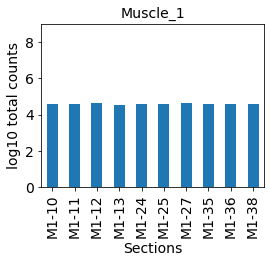

M2-8     38126.206152
M2-9     37252.647721
M2-10    35552.667805
M2-11    36960.333063
M2-22    36501.473390
M2-23    36011.100303
M2-24    43046.454996
M2-25    39570.286726
M2-36    39107.585497
M2-37    38387.694538
M2-38    34948.947301
M2-39    40223.158467
dtype: float64
37974.04632989903


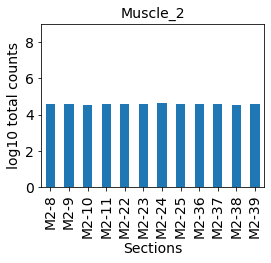

M3-1     32421.871750
M3-2     34426.602795
M3-3     33109.354632
M3-4     34043.180673
M3-17    33437.108798
M3-18    35564.030451
M3-19    33146.305116
M3-20    32846.606924
M3-33    32040.082802
M3-34    32393.081892
M3-35    32337.356304
M3-36    34839.315038
dtype: float64
33383.74143125615


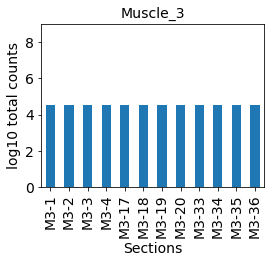

In [6]:
for key in data_norm_split:
    df=data_norm_split[key]
    print(df.sum())
    print(np.mean(df.sum()))
    # Compute log10 of column sums
    log_sums = np.log10(df.sum())

    # Plot
    plt.figure(figsize=(4,3))
    log_sums.plot(kind="bar")

    plt.ylabel("log10 total counts", fontsize=14)
    plt.title(key, fontsize=14)
    plt.xlabel('Sections', fontsize=14)
    # Optionally, adjust tick label font size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0,9)
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.size"] = 14
    #plt.savefig(f'{key} coverage barplot.svg', format='svg', dpi=300, bbox_inches='tight') 
    plt.show()

In [7]:
data_total_norm={}
data_total_norm['Muscle_1']= data_normal['shared_filtered_merged'].iloc[:,:10].sum(axis=1)
data_total_norm['Muscle_2']= data_normal['shared_filtered_merged'].iloc[:,10:22].sum(axis=1)
data_total_norm['Muscle_3']= data_normal['shared_filtered_merged'].iloc[:,22:].sum(axis=1)
data_total_norm

{'Muscle_1': ENSMUSG00000042686_Jph1_ProteinCoding         25.539433
 ENSMUSG00000026155_Smap1_ProteinCoding        78.343058
 ENSMUSG00000026154_Sdhaf4_ProteinCoding      309.947886
 ENSMUSG00000061518_Cox5b_ProteinCoding       125.294518
 ENSMUSG00000058407_Txndc9_ProteinCoding       72.272559
                                                ...     
 ENSMUSG00000041115_Iqsec2_ProteinCoding     2159.588279
 ENSMUSG00000071708_Sms_ProteinCoding        2017.565386
 ENSMUSG00000046873_Mbtps2_ProteinCoding     7065.015190
 ENSMUSG00000040990_Sh3kbp1_ProteinCoding    5549.854604
 ENSMUSG00000049775_Tmsb4x_ProteinCoding     3630.681885
 Length: 682, dtype: float64,
 'Muscle_2': ENSMUSG00000042686_Jph1_ProteinCoding         20.190397
 ENSMUSG00000026155_Smap1_ProteinCoding       130.939061
 ENSMUSG00000026154_Sdhaf4_ProteinCoding      287.085795
 ENSMUSG00000061518_Cox5b_ProteinCoding       263.160449
 ENSMUSG00000058407_Txndc9_ProteinCoding      186.853376
                                  

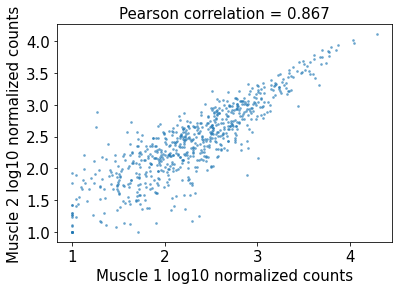

In [8]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_1'].index)
my_list1=list(data_total_norm['Muscle_1'])
data_frame['Muscle_1']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_2'])
data_frame['Muscle_2']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_1'], data_frame['Muscle_2'])

data_frame.plot(x='Muscle_1', y='Muscle_2', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 1 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 2 log10 normalized counts', fontsize=15)
plt.show()

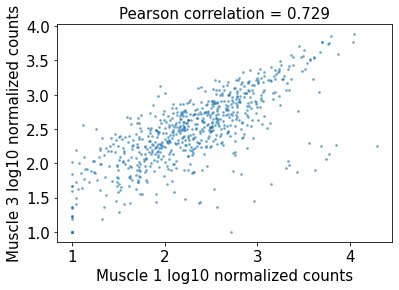

In [9]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_1'].index)
my_list1=list(data_total_norm['Muscle_1'])
data_frame['Muscle_1']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_3'])
data_frame['Muscle_3']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_1'], data_frame['Muscle_3'])

data_frame.plot(x='Muscle_1', y='Muscle_3', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 1 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 3 log10 normalized counts', fontsize=15)
plt.show()

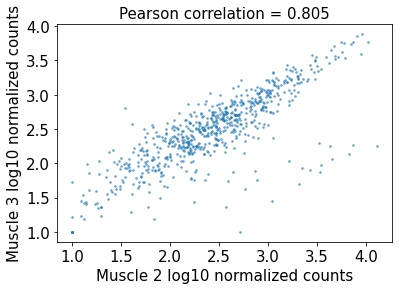

In [10]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_2'].index)
my_list1=list(data_total_norm['Muscle_2'])
data_frame['Muscle_2']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_3'])
data_frame['Muscle_3']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_2'], data_frame['Muscle_3'])

data_frame.plot(x='Muscle_2', y='Muscle_3', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 2 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 3 log10 normalized counts', fontsize=15)
plt.show()

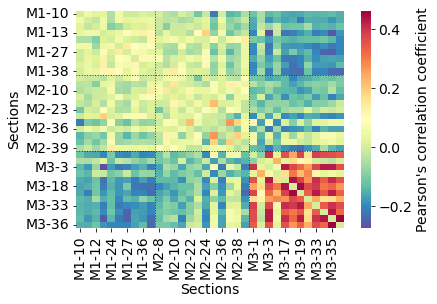

In [11]:
data_zscores = zscores(data_normal)
#correlation on zscore data for all muscle
dataframe=data_zscores['shared_filtered_merged'].astype(float)
data_corr = dataframe.corr()

#replace 1 for 0 (correlations of same section)
for index in data_corr.index:
    data_corr.loc[index,index] = 0

ax = plt.axes()
g = sns.heatmap(data_corr, cmap="Spectral_r", cbar_kws={'label': "Pearson's correlation coefficient"})
g.set(xlabel='Sections', ylabel='Sections')
ax.hlines([10, 10+12], *ax.get_xlim(), linestyles='dotted', alpha=0.7, color='black', linewidth=1)
ax.vlines([10, 10+12], *ax.get_xlim(), linestyles='dotted', alpha=0.7, color='black', linewidth=1)
plt.show()

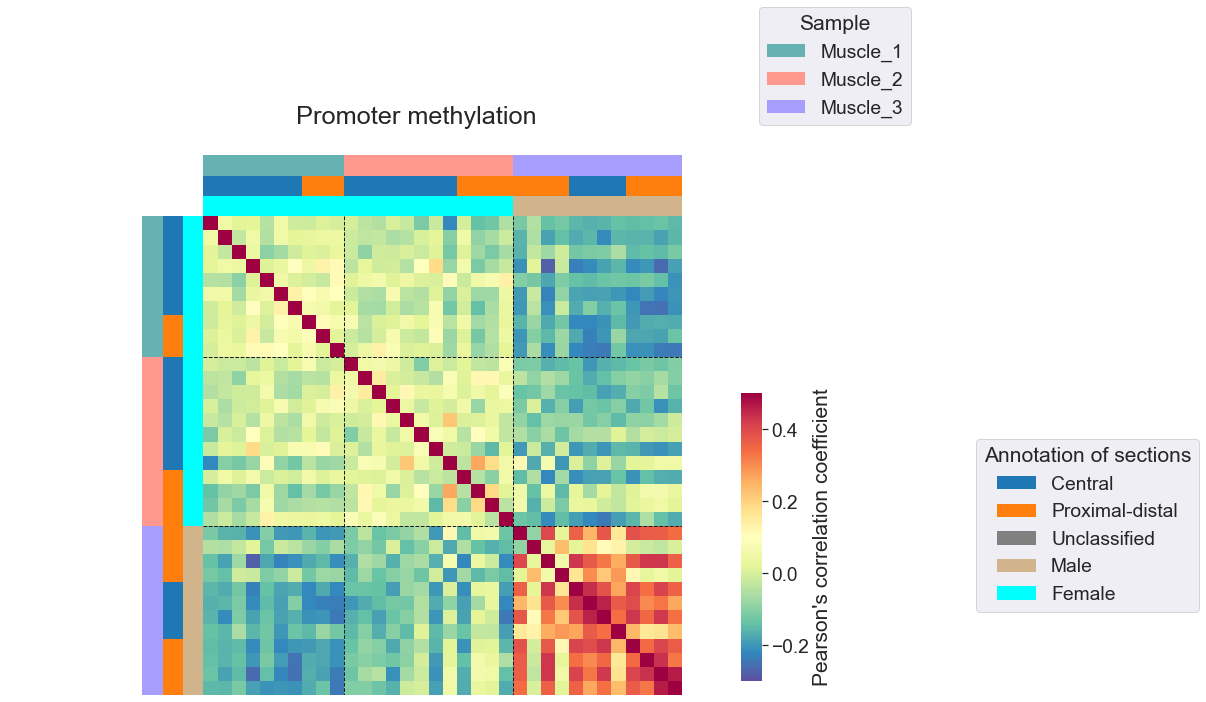

In [12]:
#assing replicates
samples=pd.Series(list(['Muscle_1']*10+['Muscle_2']*12+['Muscle_3']*12), index=list(np.arange(0,34)))
reference={'Muscle_1': '#66b2b2', 'Muscle_2': '#ff9990', 'Muscle_3': '#a79dfc'}
colors = samples.map(reference)

#assing region based on trasncriptomic data
samples2=pd.Series(list(['Central']*7+['Proximal-distal']*3+['Central']*8+['Proximal-distal']*4+['Proximal-distal']*4+['Central']*4+['Proximal-distal']*4), index=list(np.arange(0,34)))
reference2 = {'Central': 'tab:blue', 'Proximal-distal': 'tab:orange', 'Unclassified': 'grey'}
colors2 = samples2.map(reference2)

#assing sex 
samples3=pd.Series(list(['Female']*22+['Male']*12), index=list(np.arange(0,34)))
reference3 = {'Male': 'tan', 'Female': 'cyan'}
colors3 = samples3.map(reference3)

data_zscores = zscores(data_normal)
#correlation on zscore data for all muscle
dataframe=data_zscores['shared_filtered_merged'].astype(float)
data_plot = dataframe.corr().reset_index(drop=True)
data_plot.columns = list(np.arange(0,34))

# Ensure proper font settings and save
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7

sns.set(font_scale=1.75)

g = sns.clustermap(data_plot, row_cluster=False, col_cluster=False, row_colors = [colors, colors2, colors3], col_colors = [colors, colors2, colors3], cmap="Spectral_r", yticklabels=False, xticklabels=False, cbar_kws={'label': "Pearson's correlation coefficient"}, vmin=-0.3, vmax=0.5)
# Turn off the clustering
# Add colored class labels 
#add title and adjust color bar location
g.fig.suptitle('Promoter methylation', y=0.85, x=0.6)
g.ax_cbar.set_position((1.05, 0.05, .03, 0.4))

# Rasterize the heatmap only (not dendrograms, ticks, etc.)
g.ax_heatmap.set_rasterized(True)
# Legend 1: Biological replicate
for label in reference:
    g.ax_col_dendrogram.bar(0, 0, color=reference[label], label=label, linewidth=0)
g.ax_col_dendrogram.legend(
    title='Sample',
    loc="upper right",
    ncol=1,
    bbox_to_anchor=(1.3, 1),
    bbox_transform=plt.gcf().transFigure
)

# Legend 2: Cluster
for label in reference2:
    g.ax_row_dendrogram.bar(0, 0, color=reference2[label], label=label, linewidth=0)
g.ax_row_dendrogram.legend(
    title='Annotation of sections',
    loc="upper right",
    ncol=1,
    bbox_to_anchor=(1.5, 0.7),
    bbox_transform=plt.gcf().transFigure
)

# Legend 3: Cluster
for label in reference3:
    g.ax_row_dendrogram.bar(0, 0, color=reference3[label], label=label, linewidth=0)
g.ax_row_dendrogram.legend(
    title='Annotation of sections',
    loc="upper right",
    ncol=1,
    bbox_to_anchor=(1.7, 0.4),
    bbox_transform=plt.gcf().transFigure
)

#add lines delimiting muscles 
ax = g.ax_heatmap  
#ax.plot([0, len(data_clusters)], [0, 0], 'w-', lw = 2)
ax.plot([0, 34], [10, 10], 'k--', lw = 1)
ax.plot([0, 34], [10+12, 10+12], 'k--', lw = 1)



#ax.plot([0, 0], [0, len(data_clusters)], 'w-', lw = 1) 
ax.plot([10, 10], [0, 34], 'k--', lw = 1)
ax.plot([10+12, 10+12], [0, 34], 'k--', lw = 1)



plt.savefig('Correlation_heatmap_conditions_byRegion_tss.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()
 



#### logFC anterior-posterior vs center

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [11]:
data_normal_AP = data_normal['shared_filtered_merged'][['M3-1', 'M3-2', 'M3-3', 'M3-4',
    'M3-33', 'M3-34', 'M3-35', 'M3-36', 
    'M2-36','M2-37', 'M2-38', 'M2-39',
    'M1-35', 'M1-36', 'M1-38']]
data_normal_AP


,M3-1,M3-2,M3-3,M3-4,M3-33,M3-34,M3-35,M3-36,M2-36,M2-37,M2-38,M2-39,M1-35,M1-36,M1-38
ENSMUSG00000042686_Jph1_ProteinCoding,0.000000,30.036040,2.700233,0.000000,14.828795,0.000000,0.000000,6.229835,11.256501,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000026155_Smap1_ProteinCoding,34.758896,109.543206,36.903182,14.003008,39.543453,22.273936,36.531576,45.685458,25.014446,6.044354,11.710330,0.000000,12.880438,6.220368,10.928762
ENSMUSG00000026154_Sdhaf4_ProteinCoding,46.004422,2.650239,43.203725,14.936542,20.760313,33.895120,43.442955,32.187482,5.002889,12.088709,34.066414,50.108007,13.953808,34.212025,43.715049
ENSMUSG00000061518_Cox5b_ProteinCoding,39.870499,71.556449,39.603415,49.477297,42.509212,24.210800,47.392315,51.915293,0.000000,23.170025,59.616225,0.000000,4.293479,58.056770,13.660953
ENSMUSG00000058407_Txndc9_ProteinCoding,19.424089,0.000000,25.202173,27.072483,15.817381,36.800416,33.569556,58.145129,16.259390,14.103494,25.549811,0.000000,4.293479,17.624377,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,0.000000,49.471125,0.000000,3.734136,0.000000,1.936864,10.860739,2.076612,177.602569,29.214379,57.487074,315.262876,202.866894,198.015054,199.449912
ENSMUSG00000071708_Sms_ProteinCoding,5.111602,0.000000,4.500388,0.000000,8.897277,13.558048,3.949360,9.344753,157.591012,104.768809,106.457545,231.749531,272.635932,285.100209,257.736644
ENSMUSG00000046873_Mbtps2_ProteinCoding,13.290166,1.766826,13.501164,43.876093,5.931518,11.621184,29.620197,12.459670,1050.606749,293.151186,345.987020,561.627242,663.342543,509.033464,693.065676
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,5.111602,21.201911,30.602639,4.667669,9.885863,5.810592,6.911379,1.038306,835.482510,164.204960,154.363440,411.303222,637.581668,379.442460,658.457929


In [12]:
data_normal_C = data_normal['shared_filtered_merged'][['M1-10', 'M1-11', 'M1-12', 'M1-13',
    'M2-8', 'M2-9', 'M2-10', 'M2-11', 
    'M3-17', 'M3-18','M3-19', 'M3-20',
    'M2-22', 'M2-23', 'M2-24', 'M2-25']]
data_normal_C

,M1-10,M1-11,M1-12,M1-13,M2-8,M2-9,M2-10,M2-11,M3-17,M3-18,M3-19,M3-20,M2-22,M2-23,M2-24,M2-25
ENSMUSG00000042686_Jph1_ProteinCoding,0.000000,0.000000,8.331541,17.207892,0.000000,0.000000,0.000000,0.000000,0.000000,25.009867,13.282963,7.382919,5.023046,3.910849,0.000000,0.000000
ENSMUSG00000026155_Smap1_ProteinCoding,25.452612,0.000000,1.190220,7.647952,3.196273,24.626268,7.854340,13.843253,18.568803,24.083575,18.596148,15.688703,14.064530,12.710260,7.295855,4.579152
ENSMUSG00000026154_Sdhaf4_ProteinCoding,0.000000,1.594197,42.847926,2.867982,0.000000,18.715963,46.144245,0.000000,48.632579,34.272780,33.650172,26.763082,21.096795,32.264507,41.039183,26.559083
ENSMUSG00000061518_Cox5b_ProteinCoding,0.000000,0.000000,4.760881,13.383916,12.785091,11.820609,8.836132,0.000000,45.095664,38.904237,48.704197,40.606055,20.092185,52.796465,32.831346,41.212371
ENSMUSG00000058407_Txndc9_ProteinCoding,0.000000,12.753577,17.853303,11.471928,0.000000,9.850507,25.526603,39.222551,21.221489,9.262914,19.481679,21.225892,9.041483,10.754836,20.975582,15.569118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,156.631458,176.955887,457.044547,166.342952,155.551938,148.742657,190.467733,155.736601,6.189601,8.336622,0.000000,16.611568,155.714438,76.261561,71.134584,74.182267
ENSMUSG00000071708_Sms_ProteinCoding,203.620895,38.260732,314.218126,168.254940,24.504757,157.608113,181.631601,531.811653,8.842287,9.262914,4.427654,7.382919,269.235286,151.545410,215.227715,74.182267
ENSMUSG00000046873_Mbtps2_ProteinCoding,957.409784,848.112900,806.969278,494.248887,959.947233,702.341156,422.170749,1112.074692,10.610745,12.968079,13.282963,8.305784,398.829882,400.862053,837.199332,281.159952
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,1425.346264,492.606929,507.033794,534.400634,592.375873,286.649756,502.677729,412.990394,1.768457,2.778874,12.397432,1.845730,399.834491,218.029848,315.545718,229.873446


In [13]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered_merged'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

,A-P,C
ENSMUSG00000042686_Jph1_ProteinCoding,4.336760,5.009317
ENSMUSG00000026155_Smap1_ProteinCoding,27.469428,12.462371
ENSMUSG00000026154_Sdhaf4_ProteinCoding,28.681847,23.528031
ENSMUSG00000061518_Cox5b_ProteinCoding,35.022182,23.239322
ENSMUSG00000058407_Txndc9_ProteinCoding,19.590785,15.263216
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,83.198549,125.994026
ENSMUSG00000071708_Sms_ProteinCoding,97.426741,147.501079
ENSMUSG00000046873_Mbtps2_ProteinCoding,283.258713,516.655842
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,221.737743,371.009711


In [14]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


ENSMUSG00000042686_Jph1_ProteinCoding      -0.207996
ENSMUSG00000026155_Smap1_ProteinCoding      1.140248
ENSMUSG00000026154_Sdhaf4_ProteinCoding     0.285757
ENSMUSG00000061518_Cox5b_ProteinCoding      0.591701
ENSMUSG00000058407_Txndc9_ProteinCoding     0.360116
                                              ...   
ENSMUSG00000041115_Iqsec2_ProteinCoding    -0.598725
ENSMUSG00000071708_Sms_ProteinCoding       -0.598336
ENSMUSG00000046873_Mbtps2_ProteinCoding    -0.867083
ENSMUSG00000040990_Sh3kbp1_ProteinCoding   -0.742603
ENSMUSG00000049775_Tmsb4x_ProteinCoding    -0.627704
Length: 682, dtype: float64

In [15]:
list_idx=[index.split('_')[1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

,Gene,log2FC A-P vs C
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.207996
ENSMUSG00000026155_Smap1_ProteinCoding,Smap1,1.140248
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Sdhaf4,0.285757
ENSMUSG00000061518_Cox5b_ProteinCoding,Cox5b,0.591701
ENSMUSG00000058407_Txndc9_ProteinCoding,Txndc9,0.360116
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Iqsec2,-0.598725
ENSMUSG00000071708_Sms_ProteinCoding,Sms,-0.598336
ENSMUSG00000046873_Mbtps2_ProteinCoding,Mbtps2,-0.867083
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Sh3kbp1,-0.742603


In [16]:
df = pd.read_excel("DEG.xlsx", header=0, index_col=0)
list1=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] >= 0.4)].index
list2=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] <= -0.4)].index
df_sig=df.loc[df_FC.index]
# Create a new column based on index membership
df_sig['Annotation'] = np.where(df_sig.index.isin(list1), 'Central', 
                    np.where(df_sig.index.isin(list2), 'Proximal-distal', np.nan))
# Check the result
list_ann=df_sig.drop(['Mean z-score difference', 'Proximal-distal_s', 'Central_s', 'p_value', 'adj_p_value'], axis=1)
list_ann

,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Proximal-distal
ENSMUSG00000026155_Smap1_ProteinCoding,Proximal-distal
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Central
ENSMUSG00000061518_Cox5b_ProteinCoding,Central
ENSMUSG00000058407_Txndc9_ProteinCoding,Proximal-distal
...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Central
ENSMUSG00000071708_Sms_ProteinCoding,Proximal-distal
ENSMUSG00000046873_Mbtps2_ProteinCoding,Proximal-distal
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Central


In [17]:
df_FC_ann=pd.concat([df_FC, list_ann], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
#df_FC_ann=df_FC_ann.sort_values('log2FC A-P vs C', ascending=False)
df_FC_ann

,Gene,log2FC A-P vs C,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.207996,Proximal-distal
ENSMUSG00000030401_Rtn2_ProteinCoding,Rtn2,0.058226,Proximal-distal
ENSMUSG00000024091_Vapa_ProteinCoding,Vapa,-1.404446,Proximal-distal
ENSMUSG00000017831_Rab5a_ProteinCoding,Rab5a,-0.102974,Proximal-distal
ENSMUSG00000040694_Apobec2_ProteinCoding,Apobec2,0.545427,Proximal-distal
...,...,...,...
ENSMUSG00000002379_Ndufa11_ProteinCoding,Ndufa11,-0.169914,Central
ENSMUSG00000023939_Mrpl14_ProteinCoding,Mrpl14,0.094057,Central
ENSMUSG00000039601_Rcan2_ProteinCoding,Rcan2,-0.343920,Central
ENSMUSG00000023921_Mmut_ProteinCoding,Mmut,-0.625658,Central


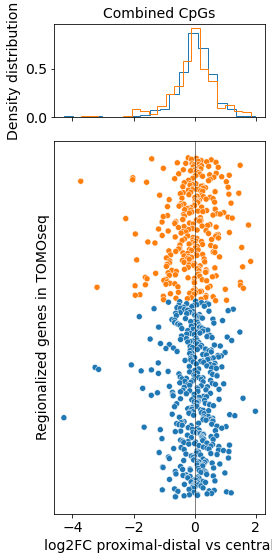

In [18]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Combined CpGs", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False  # disables legend
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD all tss.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### correlation of all sections

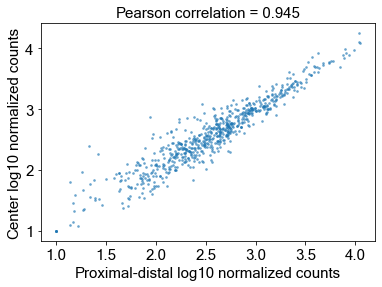

In [21]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

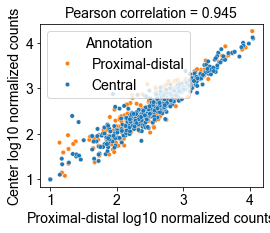

In [22]:
data_frame_ann=pd.concat([data_frame, list_ann], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=20)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD all tss.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


### Unmerged CpG information

In [52]:
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
file_names = ['shared_filtered_cpg_coverage_table_TSS3kb_normalized_DEG.bed']
labels = ['shared_filtered']


#use accessData() function to obtain a dictonary with each dataset with labels as key
data_normal = accessData4(file_names, path, labels)
data_normal['shared_filtered']

/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_90790/1401350171.py:59: DtypeWarning: Columns (0,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,4,5,6,7,8,9],  header=0)


M1-10  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                  
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
...                                                                                                                     ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  297.599769   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   

                                                                                                                 M1-11  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                             
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
...                                                                                                                ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   

                                                                                                                     M1-12  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000 

#### Reproducibility 

In [53]:
data_total_norm={}
data_total_norm['Muscle_1']= data_normal['shared_filtered'].iloc[:,:10].sum(axis=1)
data_total_norm['Muscle_2']= data_normal['shared_filtered'].iloc[:,10:22].sum(axis=1)
data_total_norm['Muscle_3']= data_normal['shared_filtered'].iloc[:,22:].sum(axis=1)
data_total_norm

{'Muscle_1': chr  start      end        Lpnp1  Lpnp1_n   chr_g  start_g    end_g      strand  gene                                   
 1    17097791   17097792   CCG    44696     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
      17097794   17097795   CCG    44697     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
      17097817   17097818   CCG    44698     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
      17097820   17097821   CCG    44699     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
      17097825   17097826   CCGG   44700     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
                                                                                                                                ...     
 X    167211004  167211005  CCGG   10922891 

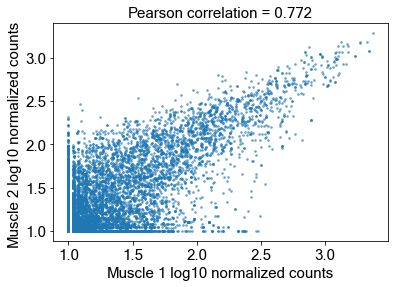

In [54]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_1'].index)
my_list1=list(data_total_norm['Muscle_1'])
data_frame['Muscle_1']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_2'])
data_frame['Muscle_2']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_1'], data_frame['Muscle_2'])

data_frame.plot(x='Muscle_1', y='Muscle_2', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 1 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 2 log10 normalized counts', fontsize=15)
plt.show()

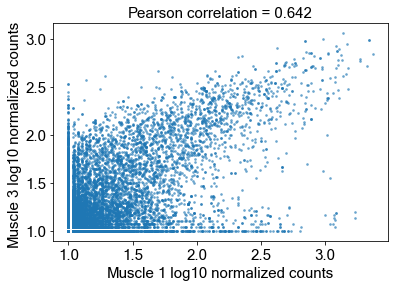

In [55]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_1'].index)
my_list1=list(data_total_norm['Muscle_1'])
data_frame['Muscle_1']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_3'])
data_frame['Muscle_3']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_1'], data_frame['Muscle_3'])

data_frame.plot(x='Muscle_1', y='Muscle_3', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 1 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 3 log10 normalized counts', fontsize=15)
plt.show()

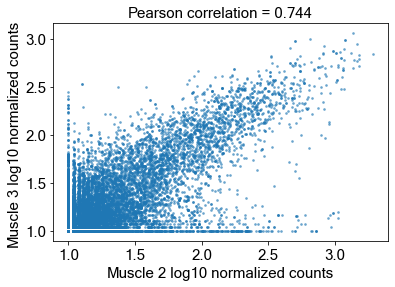

In [56]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_2'].index)
my_list1=list(data_total_norm['Muscle_2'])
data_frame['Muscle_2']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_3'])
data_frame['Muscle_3']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_2'], data_frame['Muscle_3'])

data_frame.plot(x='Muscle_2', y='Muscle_3', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 2 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 3 log10 normalized counts', fontsize=15)
plt.show()

#### logFC anterior-posterior vs center

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [57]:
data_normal_AP = data_normal['shared_filtered'][['M3-1', 'M3-2', 'M3-3', 'M3-4',
    'M3-33', 'M3-34', 'M3-35', 'M3-36', 
    'M2-36','M2-37', 'M2-38', 'M2-39',
    'M1-35', 'M1-36', 'M1-38']]
data_normal_AP


M3-1  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
...                                                                                                                   ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  8.178564   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  1.022320   

                                                                                                                      M3-2  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   4.417065   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  29.152627   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   

                                                                                                                     M3-3  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_Protei

In [58]:
data_normal_C = data_normal['shared_filtered'][['M1-10', 'M1-11', 'M1-12', 'M1-13',
    'M2-8', 'M2-9', 'M2-10', 'M2-11', 
    'M3-17', 'M3-18','M3-19', 'M3-20',
    'M2-22', 'M2-23', 'M2-24', 'M2-25']]
data_normal_C

M1-10  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                  
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
...                                                                                                                     ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  297.599769   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   

                                                                                                                 M1-11  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                             
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
...                                                                                                                ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   

                                                                                                                     M1-12  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000 

In [59]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

A-P  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   2.146077   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  27.687905   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  12.459151   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.263623   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   3.333351   

                                                                                                                         C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.119000  
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.119000  
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.057893  
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.057893  
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000  
...                                                                                                                    ...  
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   2.320052  
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  71.294044  
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  18.105127  
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   3.211254  
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.930820  

[26032 rows x 2 columns]

In [60]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


chr  start      end        Lpnp1  Lpnp1_n   chr_g  start_g    end_g      strand  gene                                   
1    17097791   17097792   CCG    44696     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -1.130932
     17097794   17097795   CCG    44697     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -1.130932
     17097817   17097818   CCG    44698     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -0.658949
     17097820   17097821   CCG    44699     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -0.658949
     17097825   17097826   CCGG   44700     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
                                                                                                                              ...   
X    167211004  167211005  CCGG   10922891  X      167209215  167212315  -       

In [61]:
list_idx=[index[-1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                               
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
...                                                                                                                                                  ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                 log2FC A-P vs C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                      
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -1.130932  
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -1.130932  
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -0.658949  
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -0.658949  
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
...                                                                                                                          ...  
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding        -0.112455  
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding        -1.364526  
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding        -0.539193  
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding        -3.606588  
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.840400  

[26032 rows x 2 columns]

In [62]:
list_ann2=pd.DataFrame(index=df_FC.index, columns=['Annotation'])
for index in df_FC.index:
    list_ann2.loc[index]['Annotation']=list_ann['Annotation'].loc[df_FC.loc[index]['Gene']]
#list_ann2["Annotation"] = list_ann2["Annotation"].str.replace("A-P", "PD", regex=False)
list_ann2

Annotation
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                    
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
...                                                                                                                          ...
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central

[26032 rows x 1 columns]

In [63]:
df_FC_ann=pd.concat([df_FC, list_ann2], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
df_FC_ann

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding        ENSMUSG00000042686_Jph1_ProteinCoding   
3   65393580  65393581  GCGC  1735809  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
    65393324  65393325  CGG   1735797  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
    65393350  65393351  CGG   1735798  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
    65393360  65393361  GCGC  1735799  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
...                                                                                                                                                    ...   
11  107470666 107470667 CGG   6979886  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
    107470657 107470658 CCG   6979885  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
    107470643 107470644 GCGC  6979884  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
    107470641 107470642 GCGC  6979883  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
X   167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                  log2FC A-P vs C  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                        
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding           -1.130932   
3   65393580  65393581  GCGC  1735809  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            0.000000   
    65393324  65393325  CGG   1735797  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            0.840382   
    65393350  65393351  CGG   1735798  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding           -1.128303   
    65393360  65393361  GCGC  1735799  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            0.000000   
...                                                                                                                           ...   
11  107470666 107470667 CGG   6979886  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         0.684508   
    107470657 107470658 CCG   6979885  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         0.000000   
    107470643 107470644 GCGC  6979884  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         1.832581   
    107470641 107470642 GCGC  6979883  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         1.832581   
X   167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          1.840400   

                                                                                                                       Annotation  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                       
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_Prote

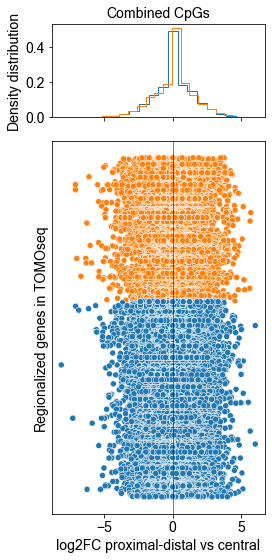

In [64]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Combined CpGs", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False,  # disables legend
    rasterized=True
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD individual tss.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### correlation of all sections

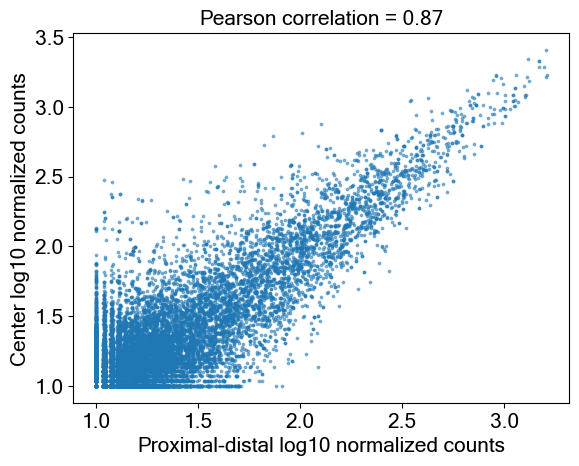

In [37]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

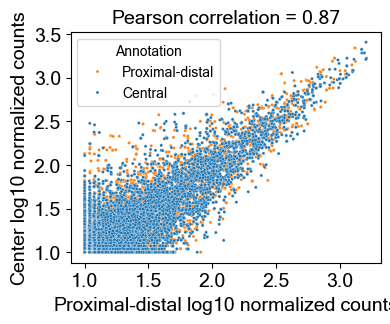

In [41]:
data_frame_ann=pd.concat([data_frame, list_ann2], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=5, rasterized=True)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD indivual tss.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
